**Predicting Heart Disease Using Logistic Regression**

Question: Can we predict the severity level of heart disease (0–4) based on patient medical features?

In [52]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("heart_disease_uci.csv")

df.head()



Saving heart_disease_uci.csv to heart_disease_uci (2).csv


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [53]:
df.shape

df.info()

df.describe()

df.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,0
ca,611
thal,486
slope,309
fbs,90
oldpeak,62
trestbps,59
exang,55
thalch,55
chol,30
restecg,2


In [54]:
df = df.drop(columns=['id'])

**Target - 'num':**

In [55]:
print(df['num'].value_counts())
print(df['num'].value_counts(normalize=True))

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64
num
0    0.446739
1    0.288043
2    0.118478
3    0.116304
4    0.030435
Name: proportion, dtype: float64


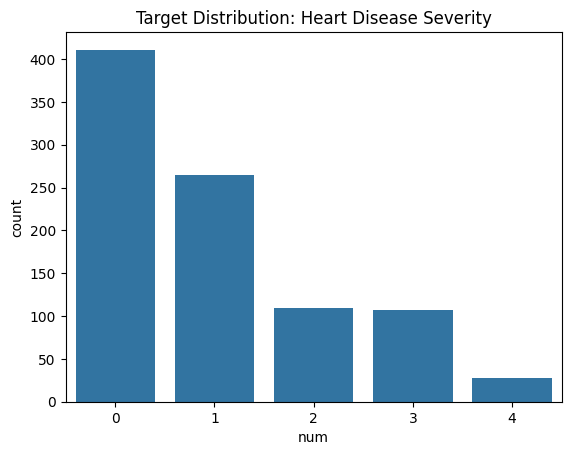

In [56]:
sns.countplot(x='num', data=df)
plt.title("Target Distribution: Heart Disease Severity")
plt.show()

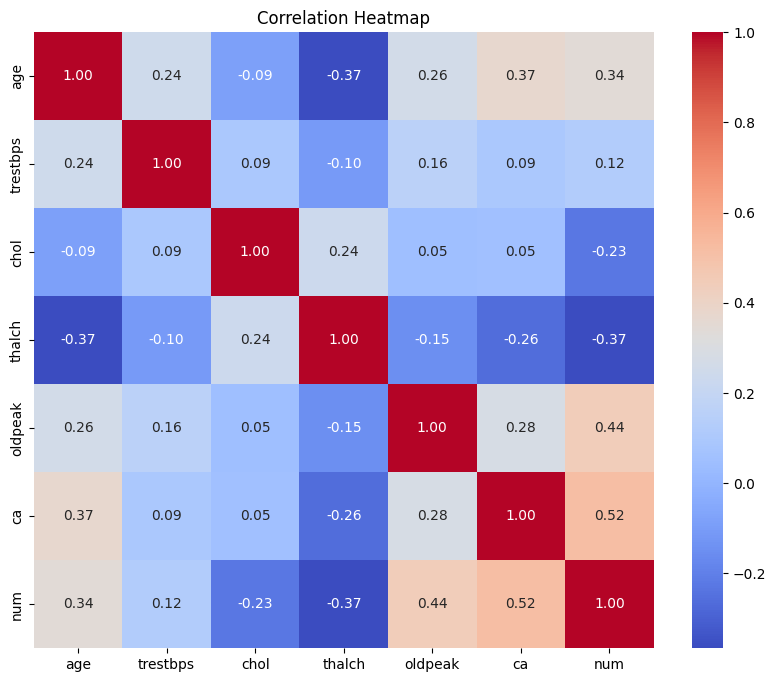

In [57]:
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The correlation analysis shows that ca has the strongest positive relationship with heart disease severity.
The variable thalch is negatively correlated, indicating that higher heart rate is associated with lower severity.
Other variables such as cholesterol and resting blood pressure show weak correlations.
No strong multicollinearity was observed among the features.

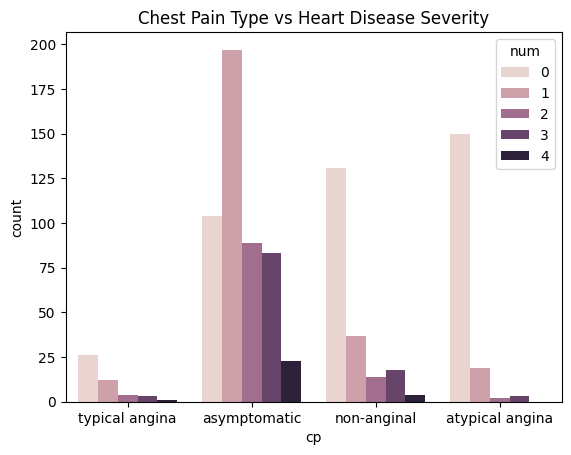

In [58]:
sns.countplot(x='cp', hue='num', data=df)
plt.title("Chest Pain Type vs Heart Disease Severity")
plt.show()

In [59]:
pd.crosstab(df['cp'], df['num'], normalize='index')

num,0,1,2,3,4
cp,,,,,
asymptomatic,0.209677,0.397177,0.179435,0.167339,0.046371
atypical angina,0.862069,0.109195,0.011494,0.017241,0.000000
non-anginal,0.642157,0.181373,0.068627,0.088235,0.019608
typical angina,0.565217,0.260870,0.086957,0.065217,0.021739


Chest pain type (cp) shows a strong relationship with heart disease severity, indicating its importance as a predictive feature.

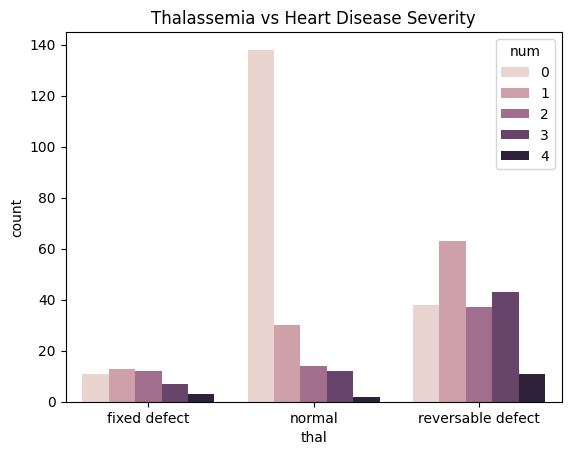

In [60]:
sns.countplot(x='thal', hue='num', data=df)
plt.title("Thalassemia vs Heart Disease Severity")
plt.show()

In [61]:
pd.crosstab(df['thal'], df['num'], normalize='index')

num,0,1,2,3,4
thal,,,,,
fixed defect,0.239130,0.282609,0.260870,0.152174,0.065217
normal,0.704082,0.153061,0.071429,0.061224,0.010204
reversable defect,0.197917,0.328125,0.192708,0.223958,0.057292


Thalassemia (thal) appears to be strongly associated with heart disease severity, with certain categories showing higher proportions of severe cases.

In [62]:
X = df.drop(columns=['num'])
y = df['num']

In [63]:
df['age_group'] = pd.cut(df['age'], bins=[0,40,60,100], labels=['young','middle','old'])

In [64]:
numeric_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
categorical_features = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'age_group']

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [66]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

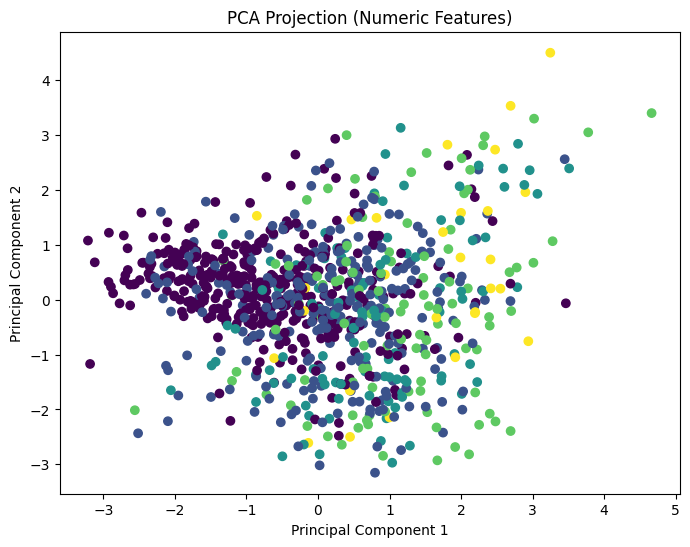

Explained variance ratio: [0.28545104 0.21976313]
Total explained variance: 0.5052141620429625


In [67]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

X_numeric = df[numeric_cols]

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_numeric)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.title("PCA Projection (Numeric Features)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

In [68]:
X = df.drop(columns=['num'])
y = df['num']

In [69]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        solver='lbfgs',
        max_iter=2000
    ))
])

X = df.drop(columns=['num'])
y = df['num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.5815217391304348

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.85      0.83        82
           1       0.50      0.58      0.54        53
           2       0.12      0.05      0.07        22
           3       0.19      0.24      0.21        21
           4       0.00      0.00      0.00         6

    accuracy                           0.58       184
   macro avg       0.32      0.34      0.33       184
weighted avg       0.54      0.58      0.56       184


Confusion Matrix:

[[70  7  1  4  0]
 [14 31  4  4  0]
 [ 1 10  1 10  0]
 [ 2 13  1  5  0]
 [ 0  1  1  4  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The warning indicates that some classes are not predicted at all, resulting in undefined precision.
This highlights a key limitation of the model due to class imbalance and limited representation of minority classes.

In [70]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print("Decision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_dt))

print("Decision Tree Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.59      0.65        82
           1       0.42      0.51      0.46        53
           2       0.29      0.32      0.30        22
           3       0.19      0.24      0.21        21
           4       0.00      0.00      0.00         6

    accuracy                           0.47       184
   macro avg       0.33      0.33      0.33       184
weighted avg       0.51      0.47      0.48       184

Decision Tree Confusion Matrix:

[[48 26  5  1  2]
 [15 27  3  8  0]
 [ 0  4  7  9  2]
 [ 2  7  6  5  1]
 [ 0  0  3  3  0]]


In [71]:
# SVM
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

svm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC())
])

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print("SVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm))

print("SVM Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))



SVM Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.88      0.83        82
           1       0.54      0.60      0.57        53
           2       0.00      0.00      0.00        22
           3       0.08      0.10      0.09        21
           4       0.00      0.00      0.00         6

    accuracy                           0.58       184
   macro avg       0.28      0.32      0.30       184
weighted avg       0.51      0.58      0.54       184

SVM Confusion Matrix:

[[72  7  0  3  0]
 [13 32  2  6  0]
 [ 2  8  0 12  0]
 [ 5 11  3  2  0]
 [ 0  1  2  3  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [72]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "SVM": accuracy_score(y_test, y_pred_svm)
}

for model_name, score in results.items():
    print(f"{model_name}: {score:.3f}")

Logistic Regression: 0.582
Decision Tree: 0.473
SVM: 0.576


I compared three models: Logistic Regression, Decision Tree and SVM.
Logistic Regression and SVM showed similar performance (approximately 0.59 accuracy), while Decision Tree performed worse (0.47).
This indicates that the dataset can be effectively modeled using simpler linear approaches.
The Decision Tree model likely overfits or fails to capture general patterns, resulting in lower performance.
More complex models do not necessarily improve performance and may even perform worse if they fail to generalize well.

**Communication: **The goal of Mini-project was to predict the severity of heart disease (from 0 to 4) using patient data. This was a multi-class classification problem.
During the data analysis, several important patterns were found. Some numerical features, such as "ca" showed a clear relationship with disease severity. Also, categorical features like "thal" was very informative. For example, patients without symptoms (asymptomatic) and those with abnormal thalassemia results were more likely to have more serious heart disease.
A logistic regression model was used together with a preprocessing pipeline. The data was cleaned, missing values were handled, categorical variables were encoded, and numerical features were scaled.
The model achieved an accuracy of about 59%. It worked well for predicting patients without heart disease (class 0), but it had problems with more severe cases. In particular, it did not predict class 4 at all.
This happens because the dataset is imbalanced: there are many more healthy patients than severe cases. Also, the difference between severity levels is not always clear, which makes the task harder.
In conclusion, the model can capture general patterns in the data, but it is not reliable for predicting severe heart disease. To improve the results, it would be useful to use more advanced models or work with more balanced data. The model is not reliable for predicting severe cases due to class imbalance.